# 1. PHẦN 1: THỐNG KÊ MÔ TẢ & ĐẶC TRƯNG
## 1.1 Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột

In [117]:
import seaborn as sns
import pandas as pd
import numpy as np

df = sns.load_dataset("iris")
# ----------------- 1 ---------------------
# Hiển thị 5 dòng đầu
print(df.head())
# Số dòng, số cột và kiểu dữ liệu của từng cột
print(df.info())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None


## 1.2 Tính các chỉ số thống kê
- mean: giá trị trung bình
- median: giá trị trung vị ( chính giữa )
- mode: giá trị xuất hiện nhiều nhất
- var (variance): Phương sai - đo mức độ phân tán của dữ liệu quanh mean
- std: Độ lệch chuẩn - Khoảng cách trung bình của dữ liệu so với mean
- min: giá trị nhỏ nhất - cận dưới
- max: giá trị lớn nhất - cận trên
- Q1: mốc 25% dữ liệu
- Q3: mốc 75% dữ liệu
- IQR: Q1- Q3 - đo độ phân tán 50% dữ liệu ở giữa

In [118]:
# ----------------- 2 ---------------------
def tinh_chi_so(series: pd.Series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    return {
        "mean": round(series.mean(),3),
        "median": round(series.median(),3),
        "mode": series.mode()[0], #pandas mặc định trả về một Series
        "var": round(series.var(),3),
        "std": round(series.std(),3),
        "min": round(series.min(),3),
        "max": round(series.max(),3),
        "Q1": round(Q1,3),
        "Q3": round(Q3,3),
        "IQR": round(Q3-Q1,3)
    }
# lấy các cột có kiểu dữ liệu số
numeric_cols = df.select_dtypes(include=np.number).columns
ket_qua = {col: tinh_chi_so(df[col]) for col in numeric_cols}

# Hiển thị dưới dạng DataFrame (rows = chỉ số, columns = biến)
bang_thong_ke = pd.DataFrame(ket_qua)

# Đổi tên cột cho ngắn gọn
bang_thong_ke.columns = ['sepal length', 'sepal width', 'petal length', 'petal width']
bang_thong_ke

,sepal length,sepal width,petal length,petal width
mean,5.843,3.057,3.758,1.199
median,5.800,3.000,4.350,1.300
mode,5.000,3.000,1.400,0.200
var,0.686,0.190,3.116,0.581
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
max,7.900,4.400,6.900,2.500
Q1,5.100,2.800,1.600,0.300
Q3,6.400,3.300,5.100,1.800
IQR,1.300,0.500,3.500,1.500


## 1.3 GroupBy
### Đặc trưng về cánh hoa (`petal_length` và `petal_width`)
Đây là nơi thể hiện sự khác biệt rõ ràng nhất, gần như tách biệt hoàn toàn giữa các nhóm:

* **Chiều dài cánh hoa (`petal_length`):** Cánh hoa của `setosa` cực kỳ ngắn, trung bình chỉ **1.462 cm**. Trong khi đó, `versicolor` là **4.260 cm** và `virginica` là **5.552 cm** (gấp 3 đến 4 lần `setosa`).
* **Chiều rộng cánh hoa (`petal_width`):** `setosa` có cánh hoa siêu nhỏ với chiều rộng trung bình chỉ **0.246 cm**, trong khi hai nhóm còn lại đều lớn hơn rất nhiều (**1.326 cm** và **2.026 cm**).

###  Đặc trưng về đài hoa (`sepal_length` và `sepal_width`)
* **Chiều dài đài hoa (`sepal_length`):** Đài hoa của `setosa` ngắn nhất (**5.006 cm**), trong khi `versicolor` (**5.936 cm**) và `virginica` (**6.588 cm**) có xu hướng tiệm cận và gần nhau hơn.
* **Chiều rộng đài hoa (`sepal_width`):** Đây là đặc trưng duy nhất mà `setosa` vượt trội hơn hẳn. Đài hoa của `setosa` rất bầu bĩnh với chiều rộng trung bình là **3.428 cm**, lớn hơn rõ rệt so với `versicolor` (**2.770 cm**) và `virginica` (**2.974 cm**).

In [119]:
df.groupby("species")[numeric_cols].agg(["mean", "std"])

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

# 2. PHẦN 2: PHÂN PHỐI XÁC SUẤT
## 2.1 Vẽ histogram + KDE cho từng biến số
- sepal_length: gần như phân phối chuẩn nhưng có một chút lệch phải nhẹ
- sepal_width: rất gàn với phân phối chuẩn
- petal_length và petal_width: có hình dạng phân phối tương đối giống nhau - phân phối hai đỉnh

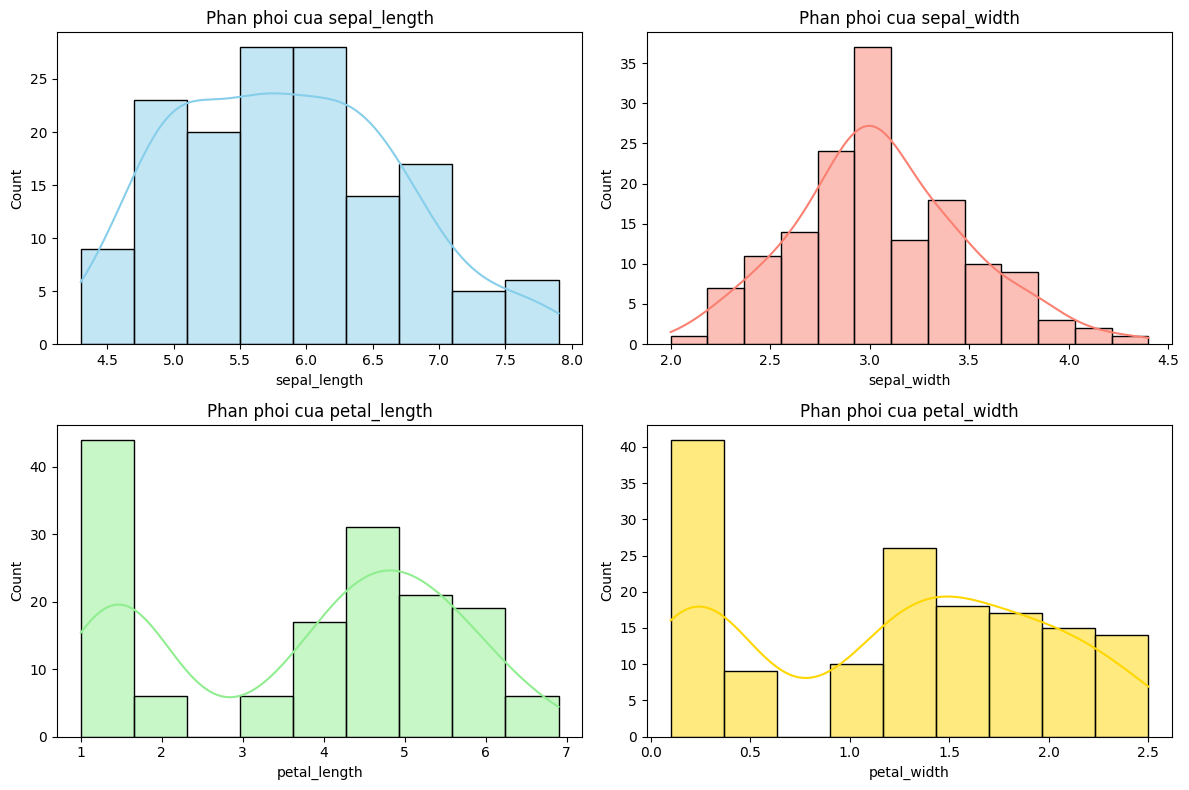

In [120]:
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=np.number).columns
# Tạo lưới 2x2 cho từng biến số
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots( nrows = 2,
                                             ncols = 2,
                                             figsize=(12, 8))
sns.histplot(data = df[numeric_cols],
             x = "sepal_length",
             kde = True,
             ax=ax1,
             color = "skyblue",
             edgecolor = "black")
ax1.set_title("Phan phoi cua sepal_length")

sns.histplot(data = df[numeric_cols],
             x = "sepal_width",
             kde = True,
             ax = ax2,
             color = "salmon",
             edgecolor = "black")
ax2.set_title("Phan phoi cua sepal_width")

sns.histplot(data = df[numeric_cols],
             x = "petal_length",
             kde = True,
             ax = ax3,
             color = "lightgreen",
            edgecolor = "black")
ax3.set_title("Phan phoi cua petal_length")

sns.histplot(data = df[numeric_cols],
             x = "petal_width",
             kde = True,
             ax = ax4,
             color = "gold",
             edgecolor = "black")
ax4.set_title("Phan phoi cua petal_width")
plt.tight_layout()
plt.show()


## 2.2 Vẽ boxplot
- sepal_length: Tăng dần setosa < versicolor < virginica, nhưng versicolor và virginica chồng lấn nhiều -> phân biệt kém
- sepal_width: setosa cao nhất, versicolor thấp nhất và virginica ở giữa, versicolor và virginica chồng lấn gần như hoàn toàn -> phân biệt kém
- pental_length và pental_width: setosa tách biệt hoàn toàn khỏi 2 lớp còn lại ( đúng với giả thuyết hai đỉnh ở 2.1 vì setosa có pental nhỏ hơn hẳn so với versicolor và virginica ) => là 2 đặc trưng có khả năng phân biệt loài tốt nhất, còn sepal_length/width kém hiệu quả hơn vì chồng lấn nhiều giữa các loài

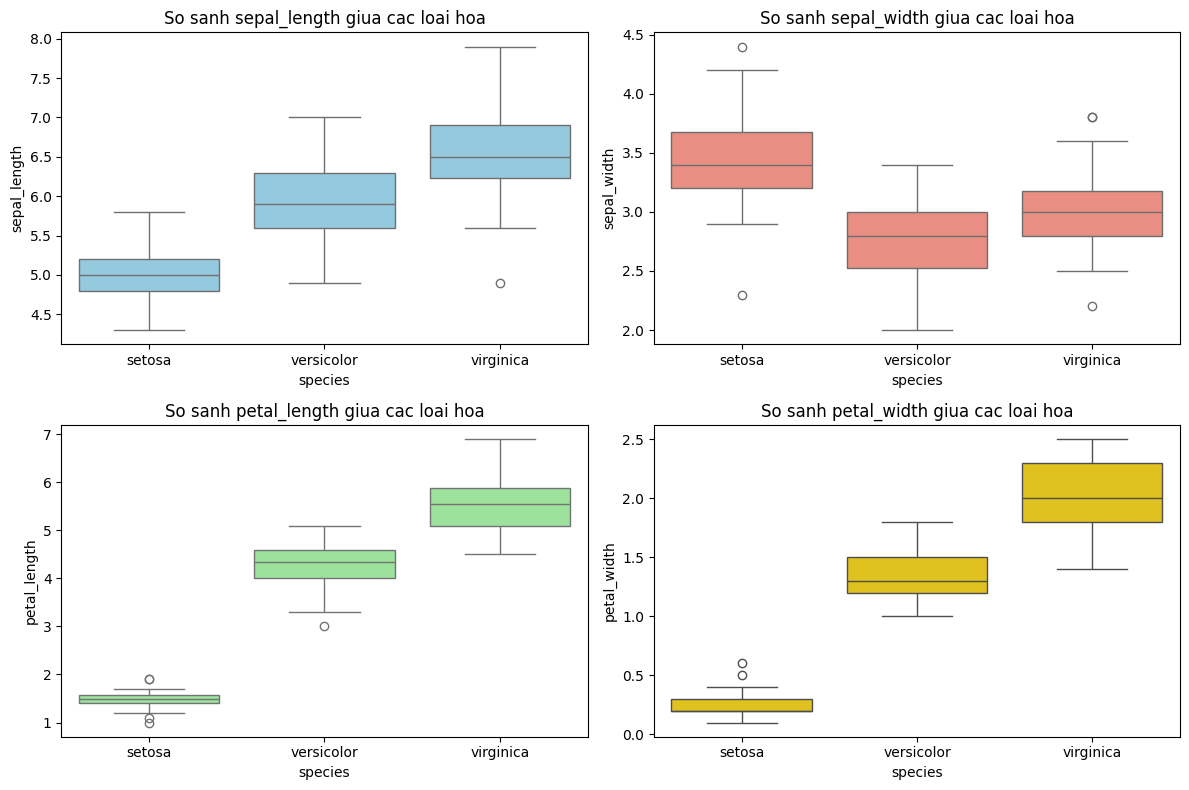

In [121]:
colors = ["skyblue", "salmon", "lightgreen", "gold"]

fig, axes = plt.subplots(nrows=2,
                         ncols=2, 
                         figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="species", y=col, ax=axes[i], color=colors[i])
    axes[i].set_title(f"So sanh {col} giua cac loai hoa")

plt.tight_layout()
plt.show()

## 2.3 Mô phỏng
Dựa vào kết quả kiểm định Shapiro-Wilk hiển thị trên biểu đồ:
* **Chỉ số:** stat = 0.9849, p-value = 0.1012
* **Quy tắc quyết định:** Với mức ý nghĩa $\alpha = 0.05$:
  * Nếu $p\text{-value} > 0.05 \rightarrow$ Chấp nhận $H_0$ (Dữ liệu có phân phối chuẩn).
  * Nếu $p\text{-value} \le 0.05 \rightarrow$ Bác bỏ $H_0$ (Dữ liệu không có phân phối chuẩn).

 **Kết luận:** Vì $p\text{-value} = 0.1012 > 0.05$, ta không bác bỏ giả thuyết $H_0$. Sự khác biệt giữa dữ liệu thực tế và lý thuyết không có ý nghĩa thống kê $\rightarrow$ **Biến `sepal_width` tuân theo phân phối chuẩn.**

Biến chọn: sepal_width
Mean = 3.0573, Std = 0.4359, n = 150
Shapiro-Wilk test: stat=0.9849, p-value=0.1012


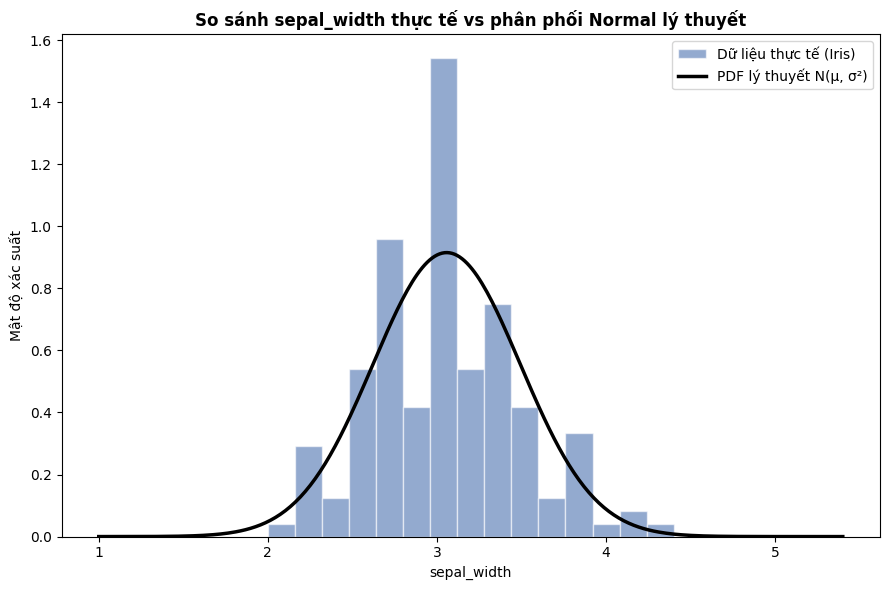

In [122]:
from sklearn.datasets import load_iris
from scipy.stats import norm, shapiro

np.random.seed(42)  # để kết quả tái lập được

# Chọn biến cần mô phỏng
bien = df.columns[1]  # sepal_width
data_thuc = df[bien]

n = len(data_thuc)
print(f"Biến chọn: {bien}")
print(f"Mean = {df[bien].mean():.4f}, Std = {df[bien].std():.4f}, n = {n}")

# Kiểm định Shapiro-Wilk xem dữ liệu thực có gần Normal không
stat, p = shapiro(data_thuc)
print(f"Shapiro-Wilk test: stat={stat:.4f}, p-value={p:.4f}")

# Vẽ histogram dữ liệu thực tế + đường PDF lý thuyết
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(data_thuc, bins=15, density=True, alpha=0.6, color='#4C72B0',
        edgecolor='white', label='Dữ liệu thực tế (Iris)')

x = np.linspace(data_thuc.min() - 1, data_thuc.max() + 1, 300)
pdf_ly_thuyet = norm.pdf(x, df[bien].mean(), df[bien].std())
ax.plot(x, pdf_ly_thuyet, color='black', linewidth=2.5, label='PDF lý thuyết N(μ, σ²)')

ax.set_title(f'So sánh {bien} thực tế vs phân phối Normal lý thuyết', fontweight='bold')
ax.set_xlabel(bien)
ax.set_ylabel('Mật độ xác suất')
ax.legend()
plt.tight_layout()
plt.savefig('mo_phong_normal_sepal_width.png', dpi=120, bbox_inches='tight')
plt.show()

# PHẦN 3: PHÂN TÍCH ĐA BIẾN & TƯƠNG QUAN
## 3.1 Tính ma trận hiệp phương sai và tương quan giữa các biến số
## 3.2 Heatmap
**Nhận xét tương quan:**

- Cặp tương quan mạnh nhất: **petal length – petal width** (r ≈ 0.96), gần như tuyến tính hoàn hảo.
- **sepal length – petal length** (r ≈ 0.87) và **sepal length – petal width** (r ≈ 0.82).
- **sepal width** gần như độc lập với 3 biến còn lại, thậm chí tương quan âm nhẹ (-0.12 đến -0.37).

**Đa cộng tuyến:** Có dấu hiệu rõ ràng. Với ngưỡng cảnh báo thường dùng |r| > 0.8, cả 3 cặp trên đều vượt ngưỡng — đặc biệt petal length/petal width gần như trùng thông tin.

→ Ảnh hưởng đến hồi quy tuyến tính: hệ số không ổn định, khó diễn giải, $X^TX$ gần suy biến. Ít ảnh hưởng với mô hình cây hoặc khi chỉ cần dự đoán. Có thể cân nhắc loại bớt 1 biến (giữ petal length, bỏ petal width) hoặc dùng PCA.


Ma trận hiệp phương sai:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        0.6857      -0.0424        1.2743       0.5163
sepal_width        -0.0424       0.1900       -0.3297      -0.1216
petal_length        1.2743      -0.3297        3.1163       1.2956
petal_width         0.5163      -0.1216        1.2956       0.5810

Ma trận tương quan:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        1.0000      -0.1176        0.8718       0.8179
sepal_width        -0.1176       1.0000       -0.4284      -0.3661
petal_length        0.8718      -0.4284        1.0000       0.9629
petal_width         0.8179      -0.3661        0.9629       1.0000


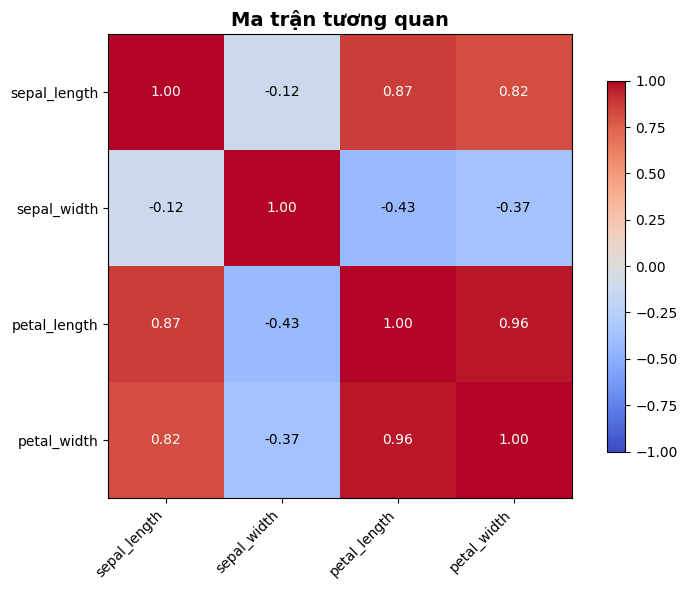

In [123]:
import matplotlib.pyplot as plt

# 1. Tính toán ma trận hiệp phương sai và tương quan (Thêm numeric_only=True)
cov_matrix = df.cov(numeric_only=True)
print("Ma trận hiệp phương sai:")
print(cov_matrix.round(4))

corr_matrix = df.corr(numeric_only=True)
print("\nMa trận tương quan:")
print(corr_matrix.round(4))

# 2. Trực quan hóa CHỈ ma trận tương quan bằng heatmap
plt.figure(figsize=(8, 6))

# Vẽ heatmap cho ma trận tương quan
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Thiết lập các trục tọa độ
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Ma trận tương quan", fontweight='bold', fontsize=14)

# Ghi số trực tiếp lên từng ô của ma trận tương quan
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        # Đổi màu chữ sang trắng nếu ô quá tối (quá gần -1 hoặc 1) để dễ đọc hơn
        color = 'white' if abs(val) > 0.5 else 'black'  # Hạ xuống 0.5 để chữ rõ hơn trên nền đỏ/xanh đậm
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=10)

# Thêm thanh thước đo màu (Colorbar)
plt.colorbar(im, shrink=0.8)

plt.tight_layout()
plt.savefig('iris_corr_only.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.3 Vẽ scatter
- Petal length và petal width có quan hệ tuyến tính rất rõ (r ≈ 0.96) — tăng cùng chiều gần như đường thẳng.
- **setosa**: tách biệt hoàn toàn (petal length/width nhỏ nhất), không chồng lấn với 2 loài kia.
- **versicolor** và **virginica**: chồng lấn nhẹ ở vùng ranh giới, nhưng virginica có xu hướng petal length/width lớn hơn.

→ Chỉ 2 biến petal length/width đã đủ phân loại tốt 3 loài, đặc biệt tách setosa gần như hoàn hảo — đây là 2 feature mạnh nhất của Iris cho bài toán classification.

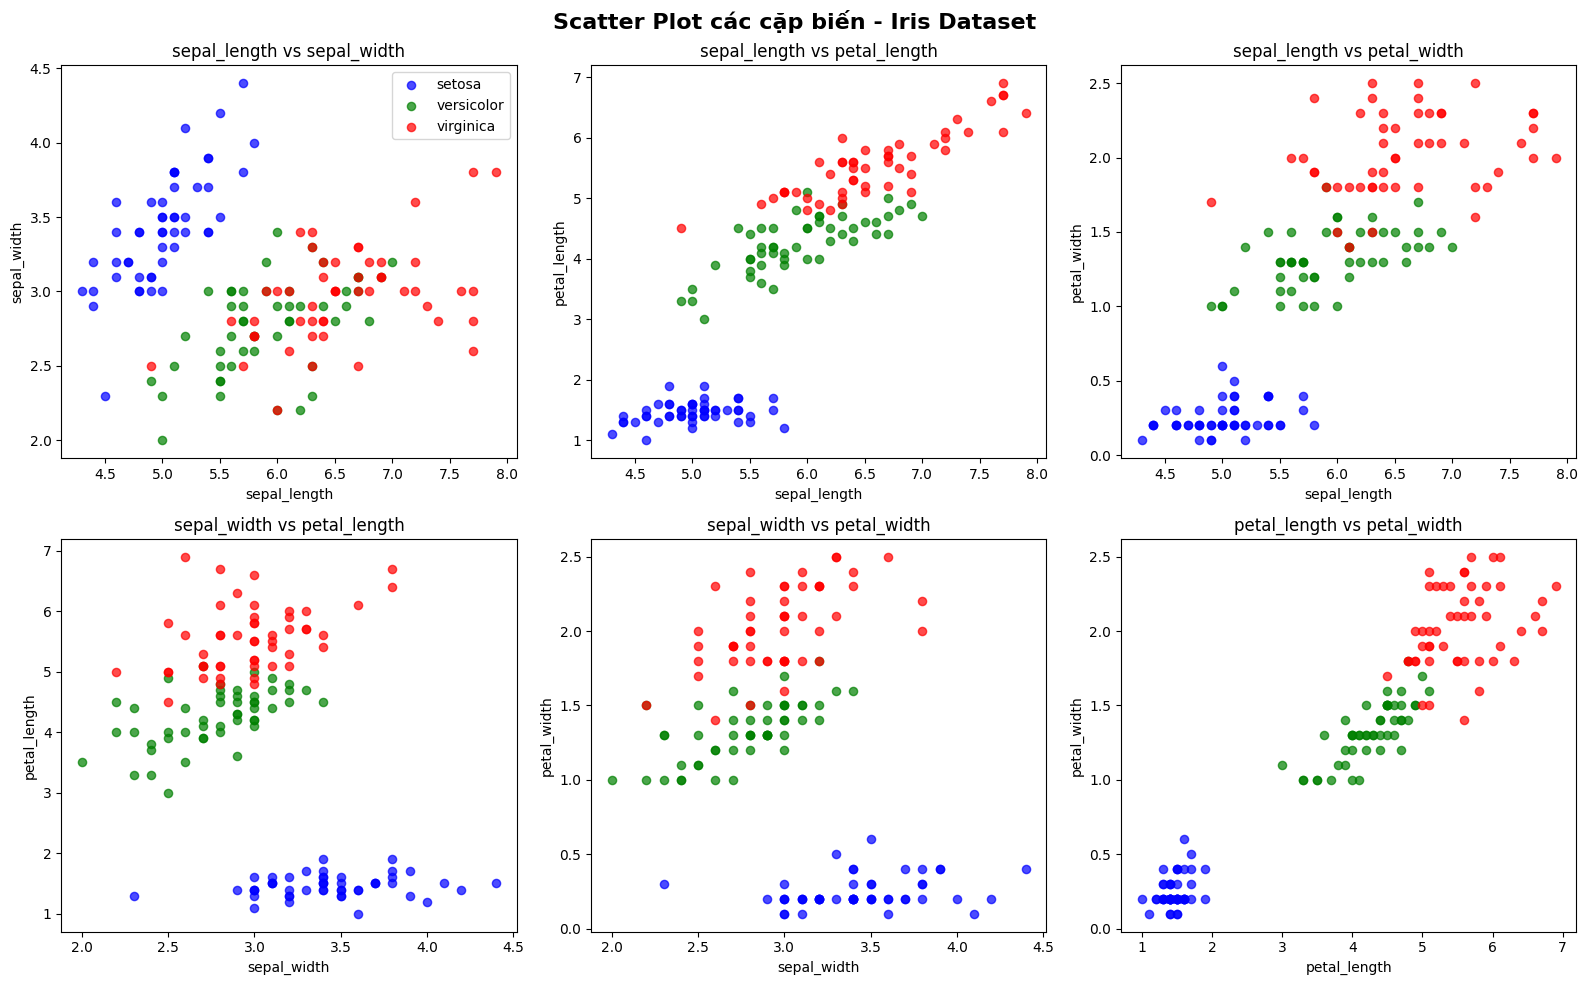

In [124]:
from sklearn.datasets import load_iris

iris = load_iris()

# Ép dữ liệu về DataFrame và đặt tên cột chuẩn hóa dạng gạch dưới
df = pd.DataFrame(iris.data, columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
df["species"] = [iris.target_names[i] for i in iris.target]

# Màu cho từng loài
colors = {
    "setosa": "blue",
    "versicolor": "green",
    "virginica": "red"
}

# Tạo 6 subplot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Scatter Plot các cặp biến - Iris Dataset", fontsize=16, fontweight="bold")

axes = axes.flatten()

# Lấy danh sách tên cột thực tế trong DataFrame (loại trừ cột 'species')
cols = [col for col in df.columns if col != "species"]

# Sinh tất cả 6 cặp biến duy nhất từ 4 biến số
pairs = [(i, j) for i in range(len(cols)) for j in range(i + 1, len(cols))]

# Vẽ scatter
for ax, (i, j) in zip(axes, pairs):
    x_col = cols[i]
    y_col = cols[j]

    for species, color in colors.items():
        subset = df[df["species"] == species]
        ax.scatter(
            subset[x_col],
            subset[y_col],
            color=color,
            label=species,
            alpha=0.7,
            s=35
        )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")

axes[0].legend()

plt.tight_layout()
plt.savefig("iris_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# PHẦN 4: XÁC SUẤT & ĐỊNH LÝ BAYES
## 4.1 Tính xác suất hậu nghiệm

In [125]:
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_not_B = 0.05

P_pos = P_pos_given_B * P_B + P_pos_given_not_B * (1 - P_B )
P_B_given_pos = P_pos_given_B * P_B / P_pos
print(f"Xác suất hậu nghiệm P(B | +) = {P_B_given_pos:.4f} ({P_B_given_pos * 100:.2f}%)")

Xác suất hậu nghiệm P(B | +) = 0.1667 (16.67%)


## 4.2 Khảo sát
Khi P(B) nhỏ, số người không mắc bệnh (¬B) áp đảo dân số. Dù tỉ lệ dương tính giả chỉ 5%, do nhóm ¬B quá đông nên **số ca dương tính giả tuyệt đối** vẫn lớn hơn nhiều so với số ca dương tính thật (từ nhóm B vốn rất ít).
**Ví dụ với P(B) = 0.01, trong 10.000 người:**
- ~100 người mắc bệnh → 99 người dương tính thật
- ~9.900 người không mắc bệnh → 5% dương tính giả ≈ 495 người

→ Tổng số dương tính = 99 + 495 = 594, trong đó chỉ 99 người thực sự mắc bệnh:

$$P(B \mid +) = \frac{99}{594} \approx 16.7\%$$

Khi P(B) tăng lên, số ca dương tính thật tăng nhanh hơn nhiều so với số ca dương tính giả, nên P(B|+) tăng nhanh và tiệm cận 1 (từ 1.9% lúc P(B)=0.001 lên 83% lúc P(B)=0.2).

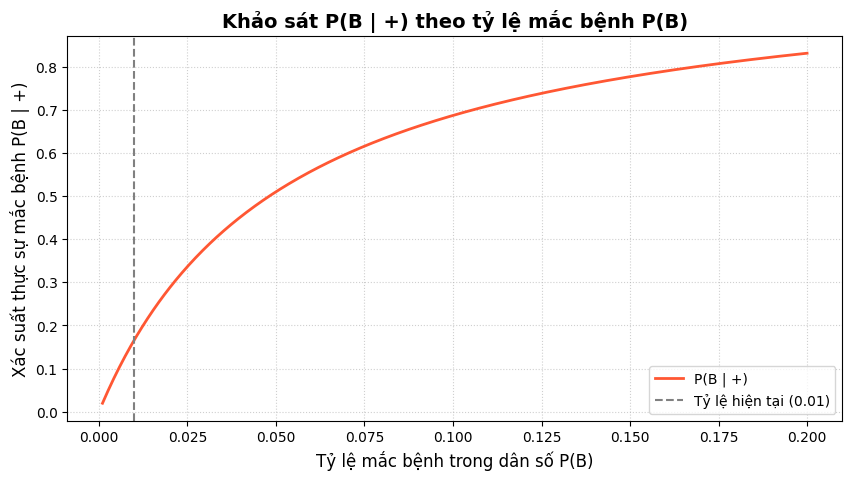

In [126]:
P_B_range = np.linspace(0.001, 0.2, 500)

P_B_given_pos_range = (P_pos_given_B * P_B_range) / (
    (P_pos_given_B * P_B_range) + (P_pos_given_not_B * (1 - P_B_range)))

# Tiến hành vẽ đồ thị
plt.figure(figsize=(10, 5))
plt.plot(P_B_range, P_B_given_pos_range, label="P(B | +)", color="#FF5733", linewidth=2)
plt.title("Khảo sát P(B | +) theo tỷ lệ mắc bệnh P(B)", fontsize=14, fontweight='bold')
plt.xlabel("Tỷ lệ mắc bệnh trong dân số P(B)", fontsize=12)
plt.ylabel("Xác suất thực sự mắc bệnh P(B | +)", fontsize=12)
plt.axvline(x=0.01, color='gray', linestyle='--', label='Tỷ lệ hiện tại (0.01)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()
 



## 4.3 Bonus


In [127]:
P_spam = 0.4 # thư rác
P_ham = 0.6 # thư thường

# Khởi tạo xác suất có điều kiện cho tập từ khóa tài chính - spam: thư rác, ham: thư thường
word_probs = {
    "vay_von":             {"spam": 0.65, "ham": 0.02},
    "lai_suat_thap":       {"spam": 0.70, "ham": 0.01},
    "kiem_tien_tai_nha":   {"spam": 0.80, "ham": 0.005},
    "thu_nhap_thu_dong":   {"spam": 0.75, "ham": 0.02},
    "dau_tu_tai_chinh":    {"spam": 0.60, "ham": 0.04},
    "giai_ngan_nhanh":     {"spam": 0.85, "ham": 0.001},
    "xoa_no":              {"spam": 0.90, "ham": 0.001},
    "tien_ao":             {"spam": 0.55, "ham": 0.01},
    "co_phieu_hot":        {"spam": 0.70, "ham": 0.02},
    # Thêm một vài từ khóa công việc thường ngày để làm đối trọng
    "bao_cao":             {"spam": 0.01, "ham": 0.45},
    "du_an":               {"spam": 0.02, "ham": 0.50}
}

def predict_spam(email_words):
    # Khởi tạo giá trị tích bằng xác suất tiên nghiệm ban đầu
    likelihood_spam = P_spam
    likelihood_ham = P_ham
    
    # Áp dụng công thức Naive Bayes
    for word in email_words:
        if word in word_probs:
            likelihood_spam *= word_probs[word]["spam"]
            likelihood_ham *= word_probs[word]["ham"]
            
    # Tính xác suất hậu nghiệm chuẩn hóa: P(spam | email)
    total_prob = likelihood_spam + likelihood_ham
    
    if total_prob == 0:
        return 0.0  # Tránh lỗi chia cho 0 
        
    p_spam_given_email = likelihood_spam / total_prob
    return round(p_spam_given_email, 4)

# 3. ví dụ
emails = {
    "Email 1 (Tín dụng đen đòi nợ/cho vay)": ["vay_von", "giai_ngan_nhanh", "lai_suat_thap"],
    "Email 2 (Lời mời đầu tư rủi ro)": ["dau_tu_tai_chinh", "tien_ao", "thu_nhap_thu_dong"],
    "Email 3 (Trao đổi công việc nội bộ)": ["du_an", "bao_cao"]
}

for name, words in emails.items():
    prob_spam = predict_spam(words)
    status = "SPAM " if prob_spam > 0.5 else "HAM (Thư thường) "
    print(f"{name}:")
    print(f"  - Các từ khóa nhận diện: {words}")
    print(f"  - P(spam | email) = {prob_spam * 100:.2f}%")
    print(f"  - Kết luận: {status}\n")

Email 1 (Tín dụng đen đòi nợ/cho vay):
  - Các từ khóa nhận diện: ['vay_von', 'giai_ngan_nhanh', 'lai_suat_thap']
  - P(spam | email) = 100.00%
  - Kết luận: SPAM 

Email 2 (Lời mời đầu tư rủi ro):
  - Các từ khóa nhận diện: ['dau_tu_tai_chinh', 'tien_ao', 'thu_nhap_thu_dong']
  - P(spam | email) = 100.00%
  - Kết luận: SPAM 

Email 3 (Trao đổi công việc nội bộ):
  - Các từ khóa nhận diện: ['du_an', 'bao_cao']
  - P(spam | email) = 0.06%
  - Kết luận: HAM (Thư thường) 

